#### **NEM Review contract co-design working group**

# Battery price spreads

## Prepare environment

In [81]:
# Data handling
import geopandas as gpd
import numpy as np
import os
import pandas as pd
import pyarrow.compute as pc

# Visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Custom functions
from scripts.common_functions import python_setup, get_mms_data, save_figure

# Set up Python
working_dir, charts_dir, data_dir = python_setup(2, dark_mode=False)

# Paths and variables
gen_info_path = os.path.join(data_dir, "gen_info.csv")
duid_data_path = os.path.join(data_dir, "duid_data.parquet")
market_data_path = os.path.join(data_dir, "market_data.parquet")
regions = ["NSW", "QLD", "SA", "VIC"]

## Prepare data

### Collect data

In [82]:
# Check if price data exists
price_data_path = os.path.join(data_dir, "price_spreads.parquet")
prices_exist = os.path.exists(price_data_path)

# Collect price data
if not prices_exist:
    price_data = get_mms_data(
        "collect_prices",
        {"start_date": "2015-01-01",
         "end_date": "2024-12-31"})
    # Pivot
    price_data = price_data.pivot(
        index="Interval",
        columns="Region",
        values="Price")
    # Save to file
    price_data.to_parquet(
        price_data_path)

# Load price data
else:
    price_data = pd.read_parquet(
        price_data_path)

# Ascribe dates
price_data["Date"] = price_data.index.to_period("D")

### Process each day's spreads and block start times

In [83]:
# Check if analysis has been done
results_path = os.path.join(data_dir, "price_spread_results.csv")
results_exist = os.path.exists(results_path)

# Empty container for analysis results with dtypes
if not results_exist:
    results = pd.DataFrame({
        "Region": pd.Series(dtype="str"),
        "Date": pd.Series(dtype="datetime64[ns]"),
        "Spread type": pd.Series(dtype="str"),
        "Price spread": pd.Series(dtype="float64"),
        "High start time": pd.Series(dtype="object"),
        "Low start time": pd.Series(dtype="object")})

    # Examine each regions
    for region in regions:
        # Examine each day
        grouped = price_data[region].groupby(price_data["Date"])
        for period_date, prices in grouped:
            date_dt = period_date.to_timestamp()
            # Examine each spread type
            for spread_type in [
                "High-low perfect (2hr)", "High-low contiguous (2hr)",
                "High-low perfect (4hr)", "High-low contiguous (4hr)",
                "Day-evening", "Overnight-morning", "Evening price"]:
                indice = len(results)
                results.at[indice, "Region"] = region
                results.at[indice, "Date"] = date_dt
                results.at[indice, "Spread type"] = spread_type
                match spread_type:
                    case "High-low perfect (2hr)":
                        day_prices = prices.copy().sort_values()
                        results.at[indice, "Price spread"] = day_prices.iloc[-24:].mean() - day_prices.iloc[:24].mean()
                    case "High-low perfect (4hr)":
                        day_prices = prices.copy().sort_values()
                        results.at[indice, "Price spread"] = day_prices.iloc[-48:].mean() - day_prices.iloc[:48].mean()
                    case "High-low contiguous (2hr)":
                        day_prices = prices.copy().rolling(window=24, min_periods=24).mean().dropna().sort_values()
                        day_prices.index = day_prices.index - pd.DateOffset(minutes=23 * 5)
                        test = day_prices.copy()
                        results.at[indice, "Price spread"] = day_prices.iloc[-1] - day_prices.iloc[0]
                        results.at[indice, "High start time"] = day_prices.index[-1].time()
                        results.at[indice, "Low start time"] = day_prices.index[0].time()
                    case "High-low contiguous (4hr)":
                        day_prices = prices.copy().rolling(window=48, min_periods=48).mean().dropna().sort_values()
                        day_prices.index = day_prices.index - pd.DateOffset(minutes=47 * 5)
                        results.at[indice, "Price spread"] = day_prices.iloc[-1] - day_prices.iloc[0]
                        results.at[indice, "High start time"] = day_prices.index[-1].time()
                        results.at[indice, "Low start time"] = day_prices.index[0].time()
                    case "Day-evening":
                        day_prices = prices.copy().sort_index()
                        times = day_prices.index.time
                        day_mask = ((times >= pd.Timestamp("09:00:00").time()) &
                                    (times < pd.Timestamp("16:00:00").time()))
                        evening_mask = ((times >= pd.Timestamp("16:00:00").time()) &
                                        (times < pd.Timestamp("21:00:00").time()))
                        day_price = day_prices[day_mask].mean()
                        evening_price = day_prices[evening_mask].mean()
                        results.at[indice, "Price spread"] = evening_price - day_price
                    case "Overnight-morning":
                        day_prices = prices.copy().sort_index()
                        times = day_prices.index.time
                        overnight_mask = ((times < pd.Timestamp("06:00:00").time()) |
                                          (times >= pd.Timestamp("21:00:00").time()))
                        morning_mask = ((times >= pd.Timestamp("06:00:00").time()) &
                                        (times < pd.Timestamp("09:00:00").time()))
                        overnight_price = day_prices[overnight_mask].mean()
                        morning_price = day_prices[morning_mask].mean()
                        results.at[indice, "Price spread"] = morning_price - overnight_price
                    case "Evening price":
                        day_prices = prices.copy().sort_index()
                        times = day_prices.index.time
                        evening_mask = ((times >= pd.Timestamp("16:00:00").time()) &
                                        (times < pd.Timestamp("21:00:00").time()))
                        evening_price = day_prices[evening_mask].mean()
                        results.at[indice, "Price spread"] = evening_price

    # Save analysis
    results.to_csv(results_path, index=False)

# Load price data
else:
    results = pd.read_csv(
        results_path,
        parse_dates=["Date"])

# Ascribe years and quarters
results["Year"] = results["Date"].dt.year
results["Quarter"] = results["Date"].dt.to_period("Q")
results["Month"] = results["Date"].dt.to_period("M")

# Display results
results

,Region,Date,Spread type,Price spread,High start time,Low start time,Year,Quarter,Month
0,NSW,2015-01-01,High-low perfect (2hr),273.260040,NaN,NaN,2015,2015Q1,2015-01
1,NSW,2015-01-01,High-low contiguous (2hr),272.537105,15:25:00,04:50:00,2015,2015Q1,2015-01
2,NSW,2015-01-01,High-low perfect (4hr),241.789505,NaN,NaN,2015,2015Q1,2015-01
3,NSW,2015-01-01,High-low contiguous (4hr),229.027257,13:55:00,04:05:00,2015,2015Q1,2015-01
4,NSW,2015-01-01,Day-evening,46.529823,NaN,NaN,2015,2015Q1,2015-01
...,...,...,...,...,...,...,...,...,...
102279,VIC,2024-12-31,High-low perfect (4hr),182.295064,NaN,NaN,2024,2024Q4,2024-12
102280,VIC,2024-12-31,High-low contiguous (4hr),176.912165,00:00:00,12:05:00,2024,2024Q4,2024-12
102281,VIC,2024-12-31,Day-evening,86.029622,NaN,NaN,2024,2024Q4,2024-12
102282,VIC,2024-12-31,Overnight-morning,-110.178168,NaN,NaN,2024,2024Q4,2024-12


## Visualise results

### Price spreads

In [84]:
spread_order = [
    "High-low perfect (2hr)", "High-low perfect (4hr)",
    "High-low contiguous (2hr)", "High-low contiguous (4hr)", 
    "Evening price", "Day-evening", "Overnight-morning"]

results["Spread type"] = pd.Categorical(results["Spread type"], categories=spread_order)
results.sort_values("Spread type", inplace=True)
results

,Region,Date,Spread type,Price spread,High start time,Low start time,Year,Quarter,Month
0,NSW,2015-01-01,High-low perfect (2hr),273.260040,NaN,NaN,2015,2015Q1,2015-01
40390,QLD,2020-10-18,High-low perfect (2hr),79.404898,NaN,NaN,2020,2020Q4,2020-10
78050,VIC,2015-07-11,High-low perfect (2hr),31.243430,NaN,NaN,2015,2015Q3,2015-07
40383,QLD,2020-10-17,High-low perfect (2hr),197.090101,NaN,NaN,2020,2020Q4,2020-10
93912,VIC,2021-09-23,High-low perfect (2hr),151.679028,NaN,NaN,2021,2021Q3,2021-09
...,...,...,...,...,...,...,...,...,...
28257,QLD,2016-01-19,Overnight-morning,5.762525,NaN,NaN,2016,2016Q1,2016-01
85328,VIC,2018-05-15,Overnight-morning,28.136919,NaN,NaN,2018,2018Q2,2018-05
57195,SA,2017-05-14,Overnight-morning,-10.116146,NaN,NaN,2017,2017Q2,2017-05
28236,QLD,2016-01-16,Overnight-morning,4.274322,NaN,NaN,2016,2016Q1,2016-01


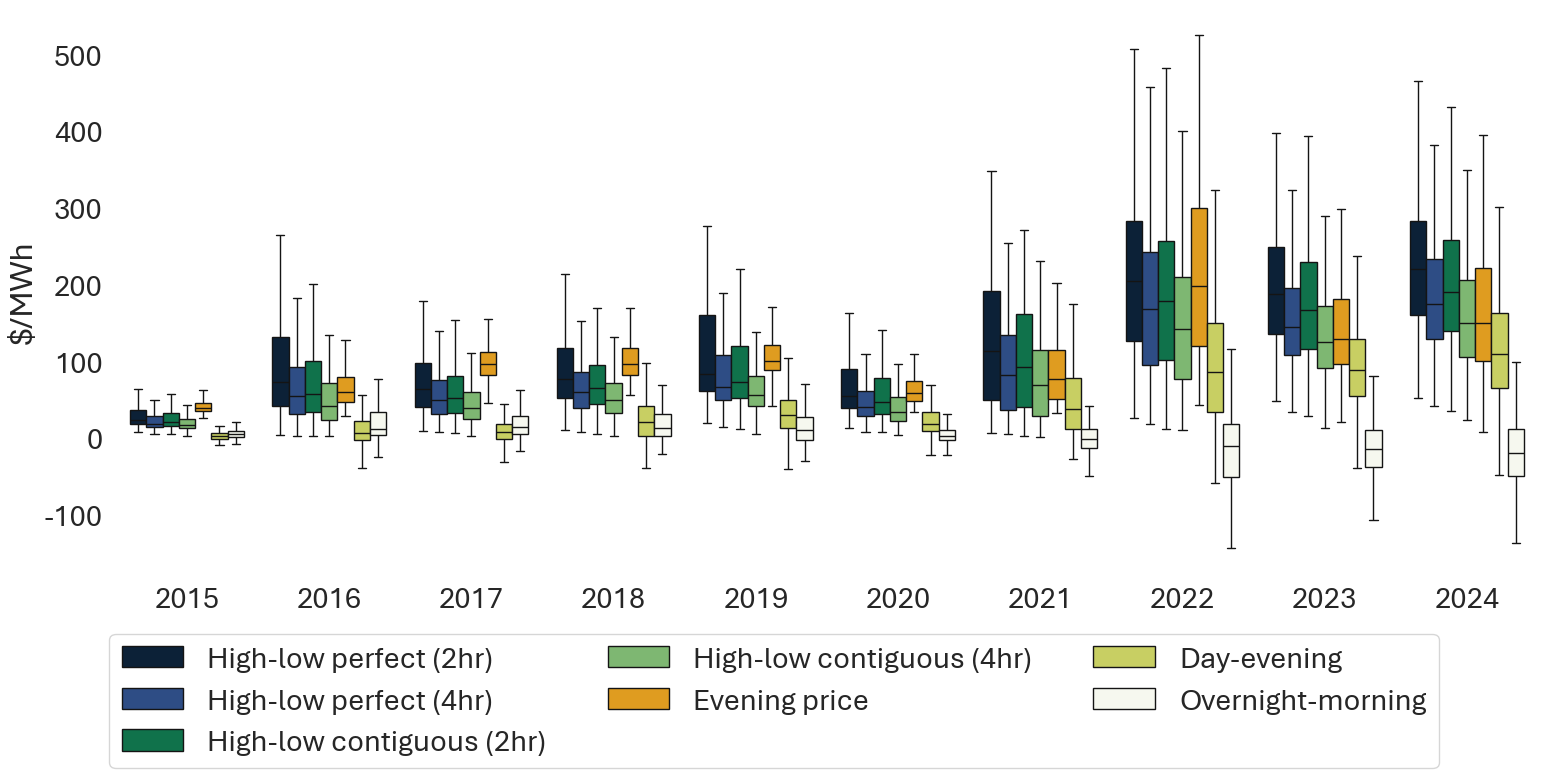

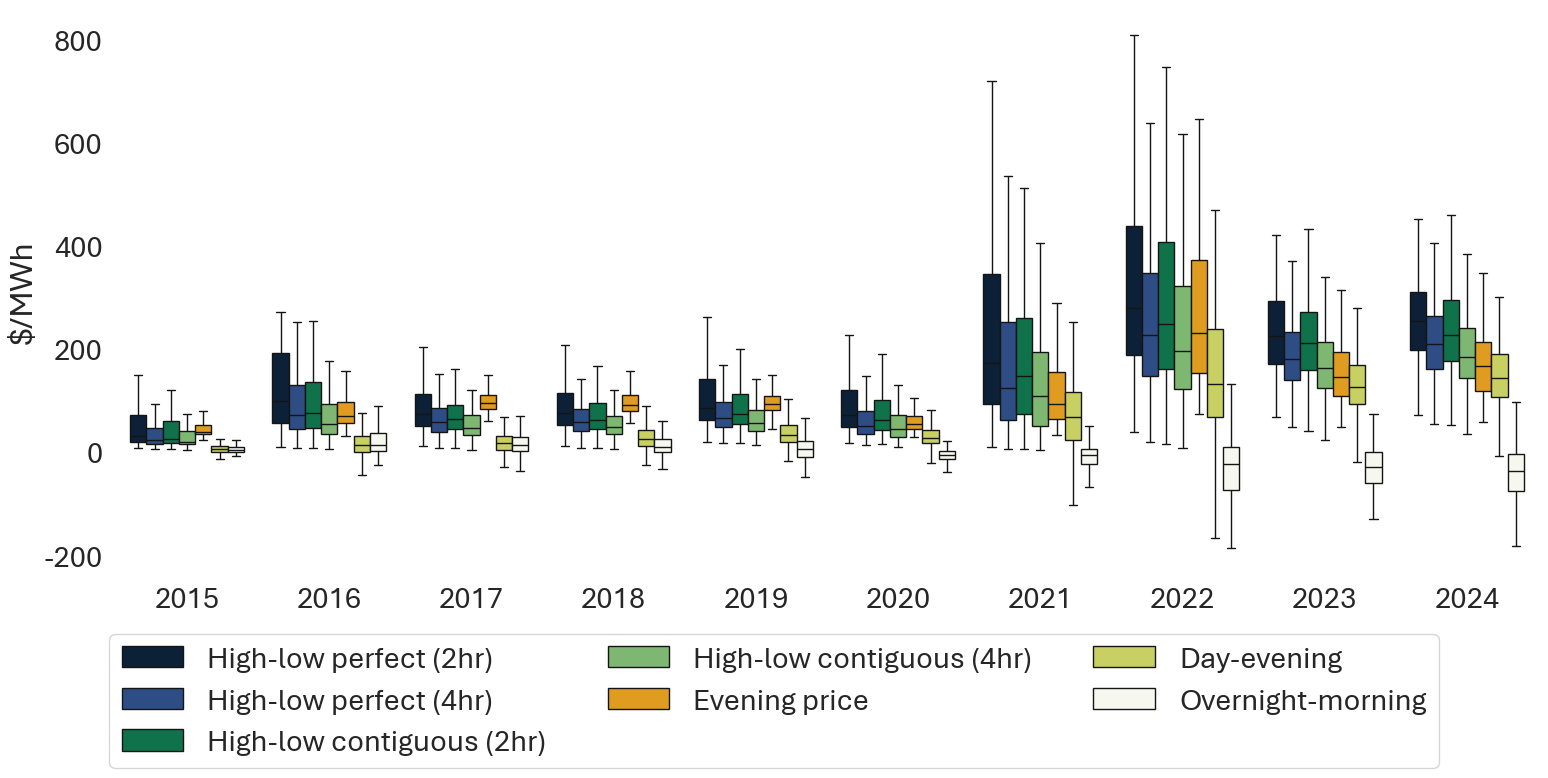

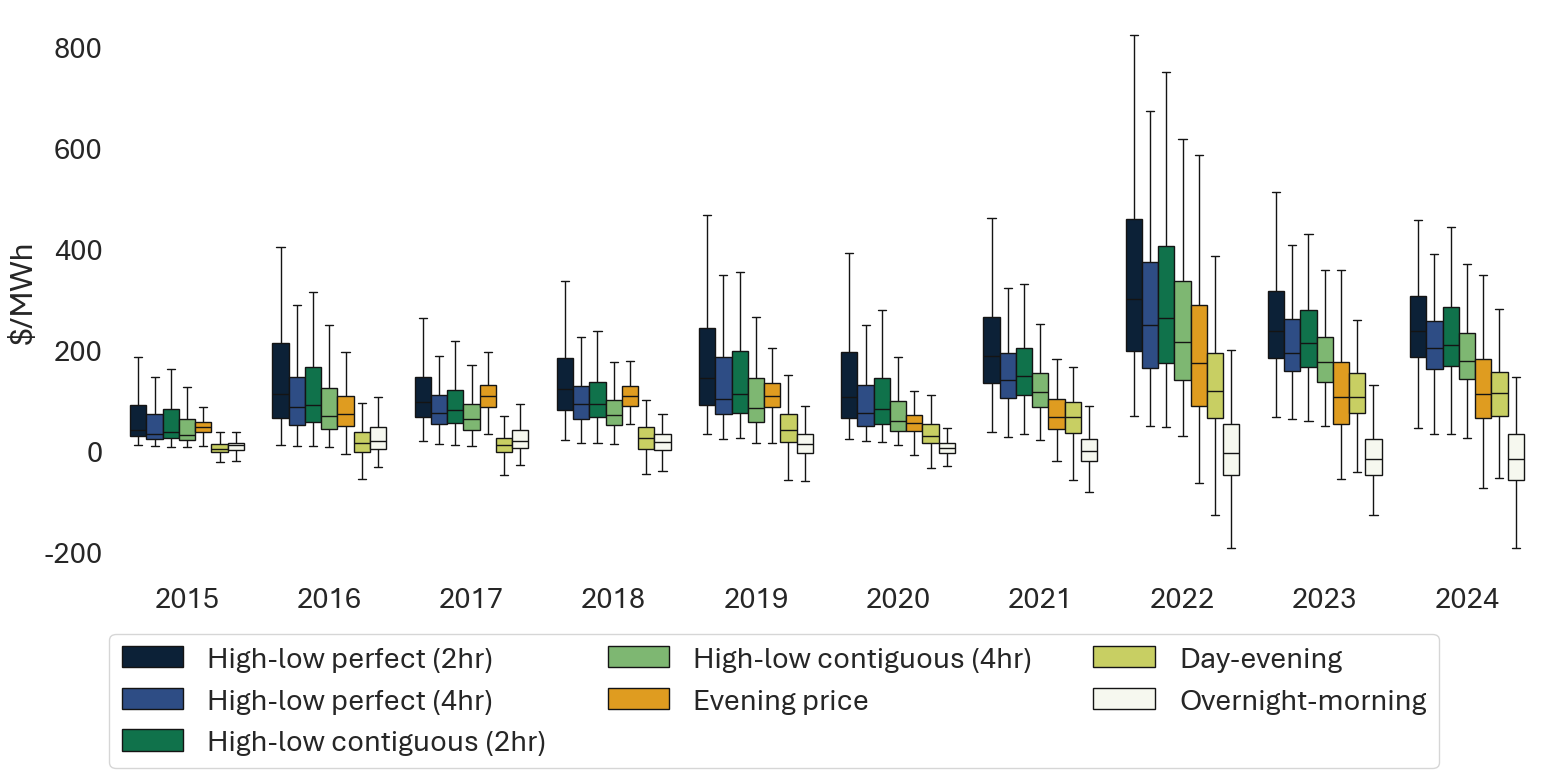

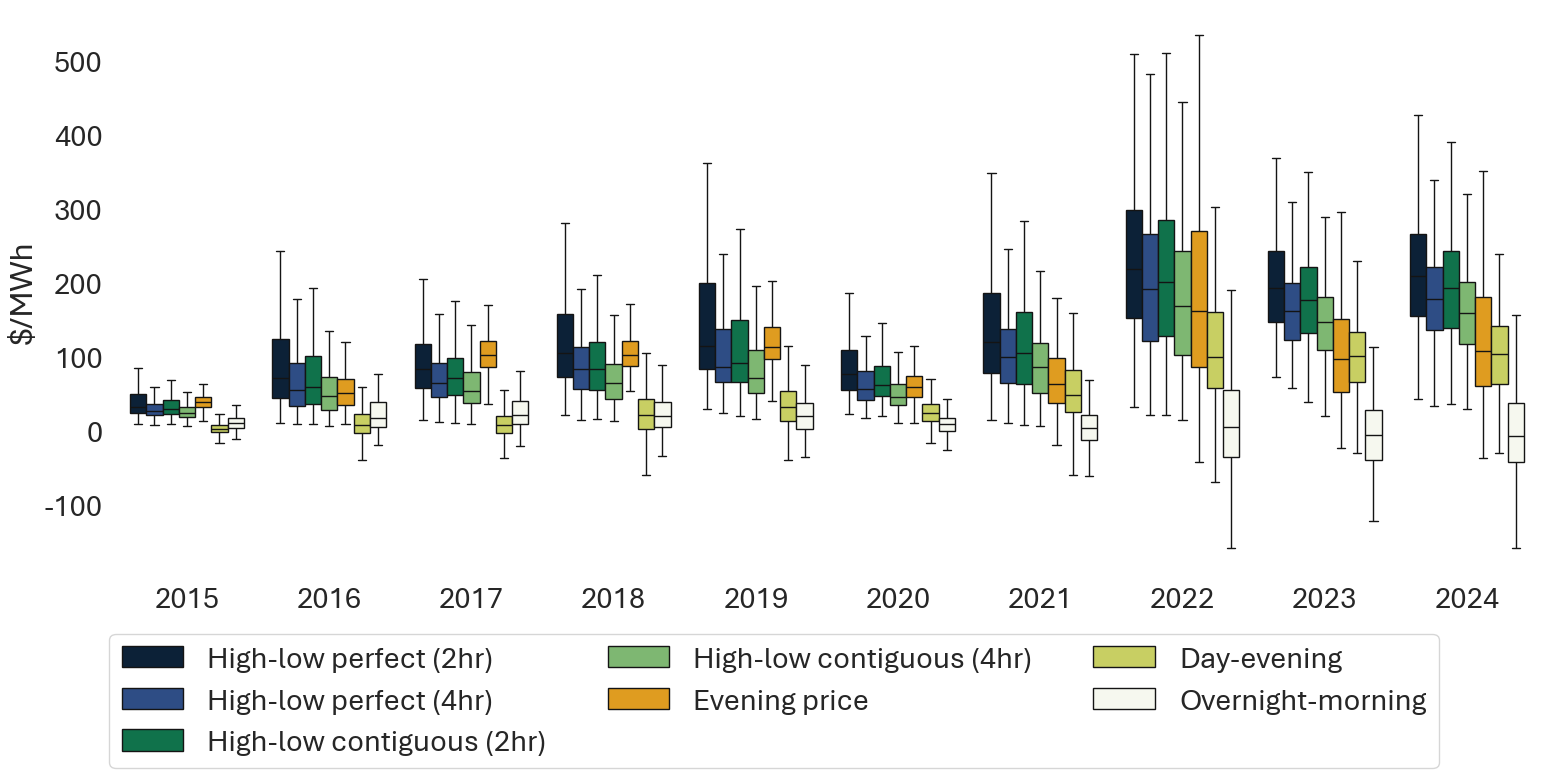

In [85]:
for region in regions:
    fig, ax = plt.subplots(
        figsize=(16, 6.75),
        tight_layout=True)
    chart_data = results[
        results["Region"] == region]
    boxplot = sns.boxplot(
        ax=ax,
        data=chart_data,
        x="Year",
        y="Price spread",
        hue="Spread type",
        palette=["C0", "C1", "C2", "C3", "orange", "C4", "C5"],
        showfliers=False)
    for frame in ["top", "right", "bottom", "left"]:
        ax.spines[frame].set_visible(False)
    plt.ylabel("$/MWh")
    plt.xlabel(None)
    ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
    handles, labels = ax.get_legend_handles_labels()
    plt.legend().remove()
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=3)
    plt.show()
    save_figure(fig, f"{region}_intraday_price_spreads_annually", charts_dir)

### Explainer visualisations

#### 4hr high-low perfect spread

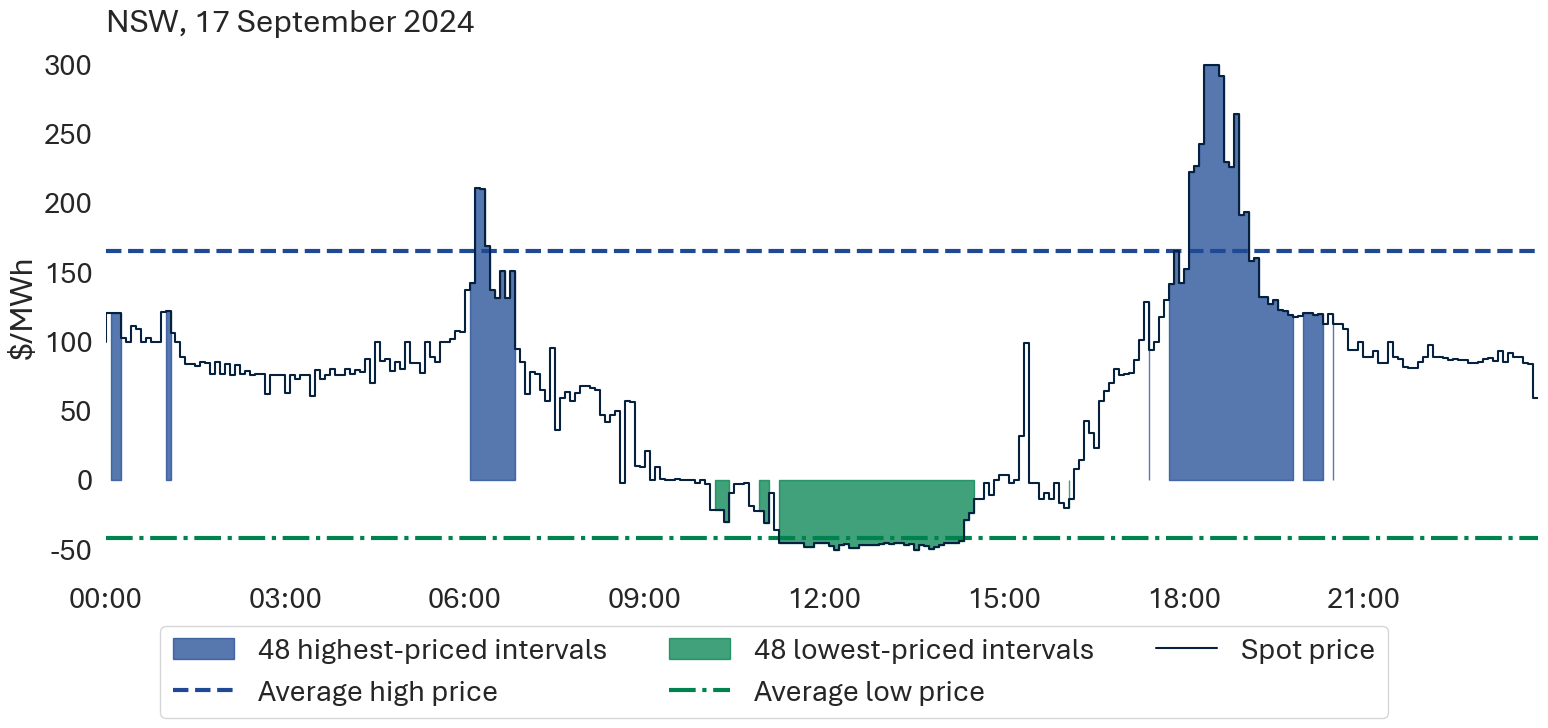

np.float64(207.2971402083333)

In [86]:
example = price_data.loc[f"2024-09-17":f"2024-09-17 23:55:00"].copy()[["NSW"]]
top = example.sort_values("NSW").index[-48:].tolist()
bottom = example.sort_values("NSW").index[:48].tolist()
example["Top"] = example.index.map(lambda x: example.at[x, "NSW"] if x in top else np.nan)
example["Bottom"] = example.index.map(lambda x: example.at[x, "NSW"] if x in bottom else np.nan)

fig, ax = plt.subplots(
    figsize=(16, 6.75),
    tight_layout=True)
ax.fill_between(
    x=example.index,
    y1=example["Top"],
    y2=0,
    color="C1",
    alpha=.75,
    step="pre",
    label="48 highest-priced intervals")
plt.axhline(
    example["Top"].mean(),
    color="C1",
    linewidth=3,
    linestyle="--",
    label="Average high price")
ax.fill_between(
    x=example.index,
    y1=example["Bottom"],
    y2=0,
    color="C2",
    step="pre",
    alpha=.75,
    label="48 lowest-priced intervals")
plt.axhline(
    example["Bottom"].mean(),
    color="C2",
    linewidth=3,
    linestyle="-.",
    label="Average low price")
ax.step(
    x=example.index,
    y=example["NSW"],
    label="Spot price")
for frame in ["top", "right", "bottom", "left"]:
    ax.spines[frame].set_visible(False)
plt.title("NSW, 17 September 2024", loc="left")
plt.ylabel("$/MWh")
plt.xlabel(None)
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.125), ncol=3)
plt.xlim(example.index.min(), example.index.max())
plt.show()
save_figure(fig, f"NSW_example_high_low_4hr_perfect_spread", charts_dir)
example["Top"].mean() - example["Bottom"].mean()

#### 4hr high-low contiguous spread

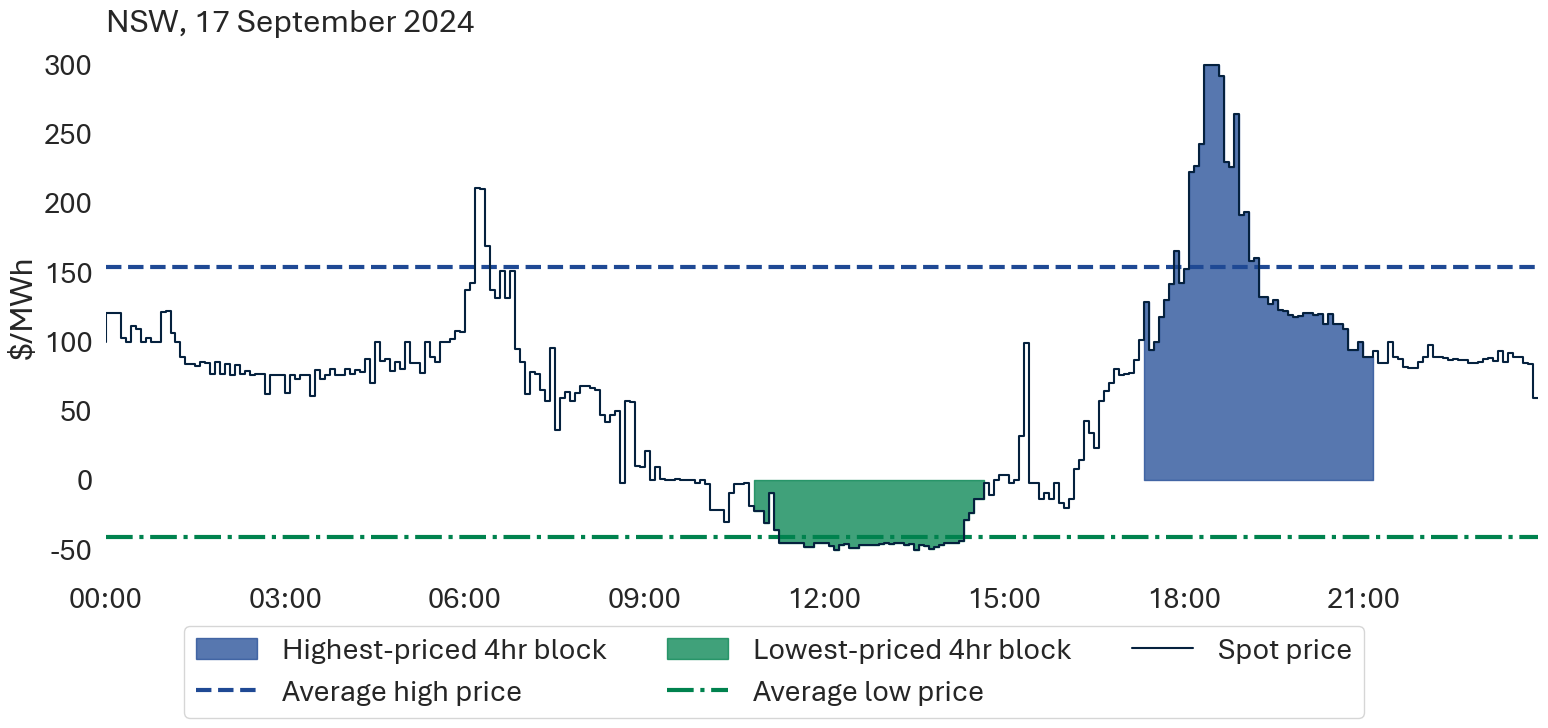

np.float64(194.84702468085106)

In [87]:
example = price_data.loc[f"2024-09-17":f"2024-09-17 23:55:00"].copy()[["NSW"]]
rolling = example.rolling(window=48, min_periods=48).mean().dropna().sort_values("NSW").copy()
top_start = rolling.index[-1] - pd.DateOffset(minutes=47 * 5)
top_end = rolling.index[-1]
bottom_start = rolling.index[0] - pd.DateOffset(minutes=47 * 5)
bottom_end = rolling.index[0]
example["Top"] = example.index.map(lambda t: example.at[t, "NSW"] if ((t >= top_start) & (t < top_end)) else np.nan)
example["Bottom"] = example.index.map(lambda t: example.at[t, "NSW"] if ((t >= bottom_start) & (t < bottom_end)) else np.nan)

fig, ax = plt.subplots(
    figsize=(16, 6.75),
    tight_layout=True)
ax.fill_between(
    x=example.index,
    y1=example["Top"],
    y2=0,
    color="C1",
    alpha=.75,
    step="pre",
    label="Highest-priced 4hr block")
plt.axhline(
    example["Top"].mean(),
    color="C1",
    linewidth=3,
    linestyle="--",
    label="Average high price")
ax.fill_between(
    x=example.index,
    y1=example["Bottom"],
    y2=0,
    color="C2",
    step="pre",
    alpha=.75,
    label="Lowest-priced 4hr block")
plt.axhline(
    example["Bottom"].mean(),
    color="C2",
    linewidth=3,
    linestyle="-.",
    label="Average low price")
ax.step(
    x=example.index,
    y=example["NSW"],
    label="Spot price")
for frame in ["top", "right", "bottom", "left"]:
    ax.spines[frame].set_visible(False)
plt.title("NSW, 17 September 2024", loc="left")
plt.ylabel("$/MWh")
plt.xlabel(None)
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.125), ncol=3)
plt.xlim(example.index.min(), example.index.max())
plt.show()
save_figure(fig, f"NSW_example_high_low_4hr_contiguous_spread", charts_dir)
example["Top"].mean() - example["Bottom"].mean()

#### Day-evening spread

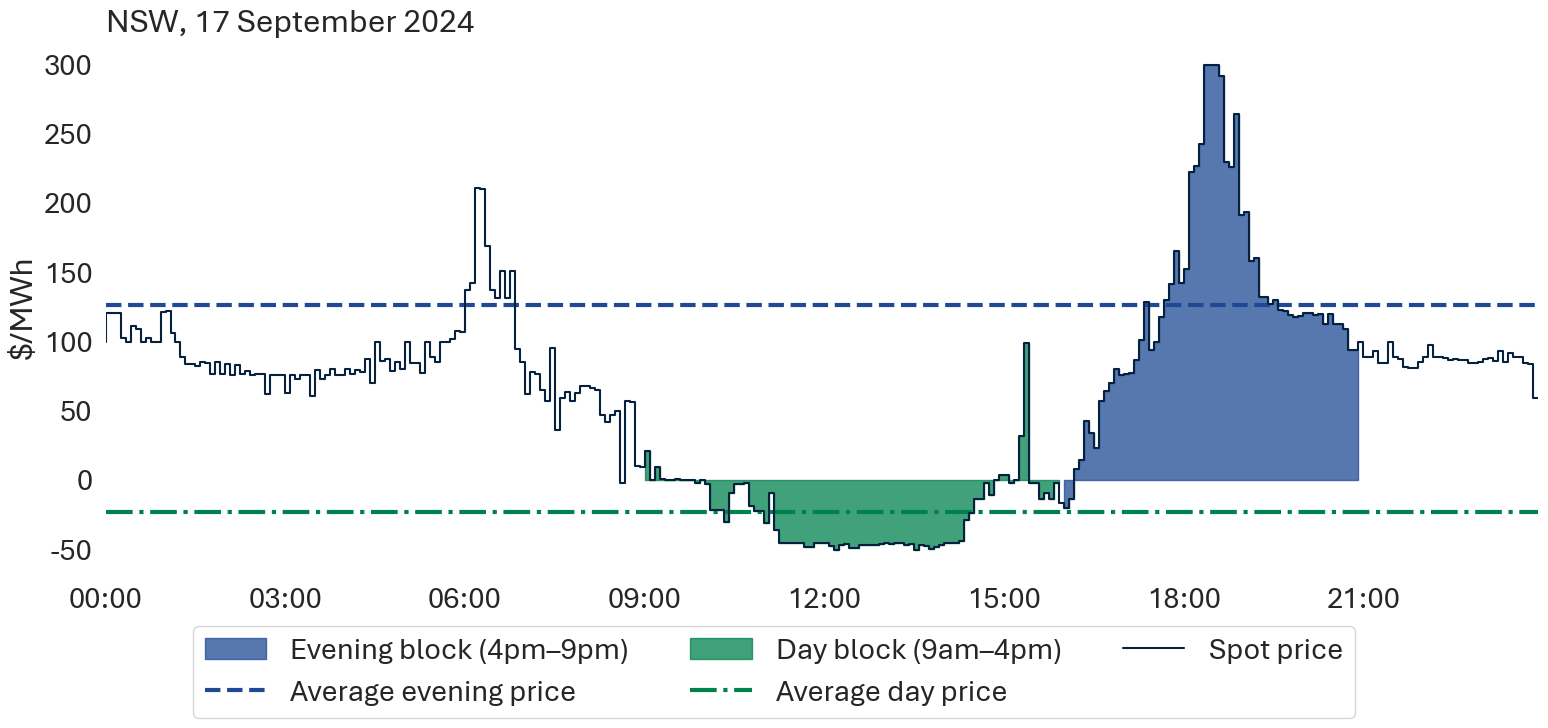

np.float64(149.73266847619047)

In [88]:
example = price_data.loc[f"2024-09-17":f"2024-09-17 23:55:00"].copy()[["NSW"]]
example["Day"] = example.index.map(lambda t: example.at[t, "NSW"] if ((t >= pd.to_datetime("2024-09-17 09:00:00")) & (t < pd.to_datetime("2024-09-17 16:00:00"))) else np.nan)
example["Evening"] = example.index.map(lambda t: example.at[t, "NSW"] if (t >= pd.to_datetime("2024-09-17 16:00:00")) & (t < pd.to_datetime("2024-09-17 21:00:00")) else np.nan)
fig, ax = plt.subplots(
    figsize=(16, 6.75),
    tight_layout=True)
ax.fill_between(
    x=example.index,
    y1=example["Evening"],
    y2=0,
    color="C1",
    alpha=.75,
    step="pre",
    label="Evening block (4pm–9pm)")
plt.axhline(
    example["Evening"].mean(),
    color="C1",
    linewidth=3,
    linestyle="--",
    label="Average evening price")
ax.fill_between(
    x=example.index,
    y1=example["Day"],
    y2=0,
    color="C2",
    step="pre",
    alpha=.75,
    label="Day block (9am–4pm)")
plt.axhline(
    example["Day"].mean(),
    color="C2",
    linewidth=3,
    linestyle="-.",
    label="Average day price")
ax.step(
    x=example.index,
    y=example["NSW"],
    label="Spot price")
for frame in ["top", "right", "bottom", "left"]:
    ax.spines[frame].set_visible(False)
plt.title("NSW, 17 September 2024", loc="left")
plt.ylabel("$/MWh")
plt.xlabel(None)
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.125), ncol=3)
plt.xlim(example.index.min(), example.index.max())
plt.show()
save_figure(fig, f"NSW_example_day_evening_spread", charts_dir)
example["Evening"].mean() - example["Day"].mean()

#### Overnight-morning spread

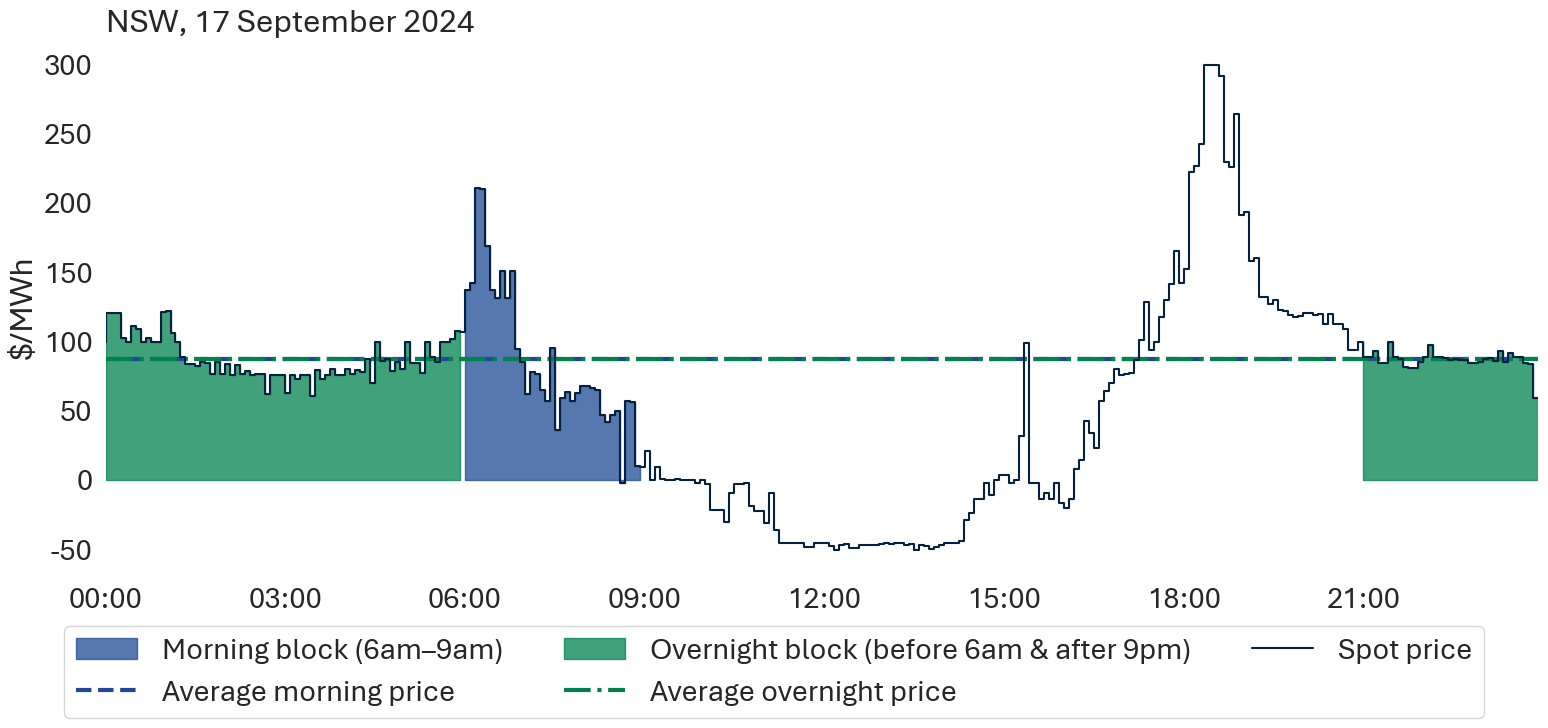

np.float64(-0.053266203703714154)

In [89]:
example = price_data.loc[f"2024-09-17":f"2024-09-17 23:55:00"].copy()[["NSW"]]
example["Overnight"] = example.index.map(lambda t: example.at[t, "NSW"] if ((t < pd.to_datetime("2024-09-17 06:00:00")) | (t >= pd.to_datetime("2024-09-17 21:00:00"))) else np.nan)
example["Morning"] = example.index.map(lambda t: example.at[t, "NSW"] if (t >= pd.to_datetime("2024-09-17 06:00:00")) & (t < pd.to_datetime("2024-09-17 09:00:00")) else np.nan)
fig, ax = plt.subplots(
    figsize=(16, 6.75),
    tight_layout=True)
ax.fill_between(
    x=example.index,
    y1=example["Morning"],
    y2=0,
    color="C1",
    alpha=.75,
    step="pre",
    label="Morning block (6am–9am)")
plt.axhline(
    example["Morning"].mean(),
    color="C1",
    linewidth=3,
    linestyle="--",
    label="Average morning price")
ax.fill_between(
    x=example.index,
    y1=example["Overnight"],
    y2=0,
    color="C2",
    step="pre",
    alpha=.75,
    label="Overnight block (before 6am & after 9pm)")
plt.axhline(
    example["Overnight"].mean(),
    color="C2",
    linewidth=3,
    linestyle="-.",
    label="Average overnight price")
ax.step(
    x=example.index,
    y=example["NSW"],
    label="Spot price")
for frame in ["top", "right", "bottom", "left"]:
    ax.spines[frame].set_visible(False)
plt.title("NSW, 17 September 2024", loc="left")
plt.ylabel("$/MWh")
plt.xlabel(None)
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.125), ncol=3)
plt.xlim(example.index.min(), example.index.max())
plt.show()
save_figure(fig, f"NSW_example_morning_overnight_spread", charts_dir)
example["Morning"].mean() - example["Overnight"].mean()

#### Evening-price spread

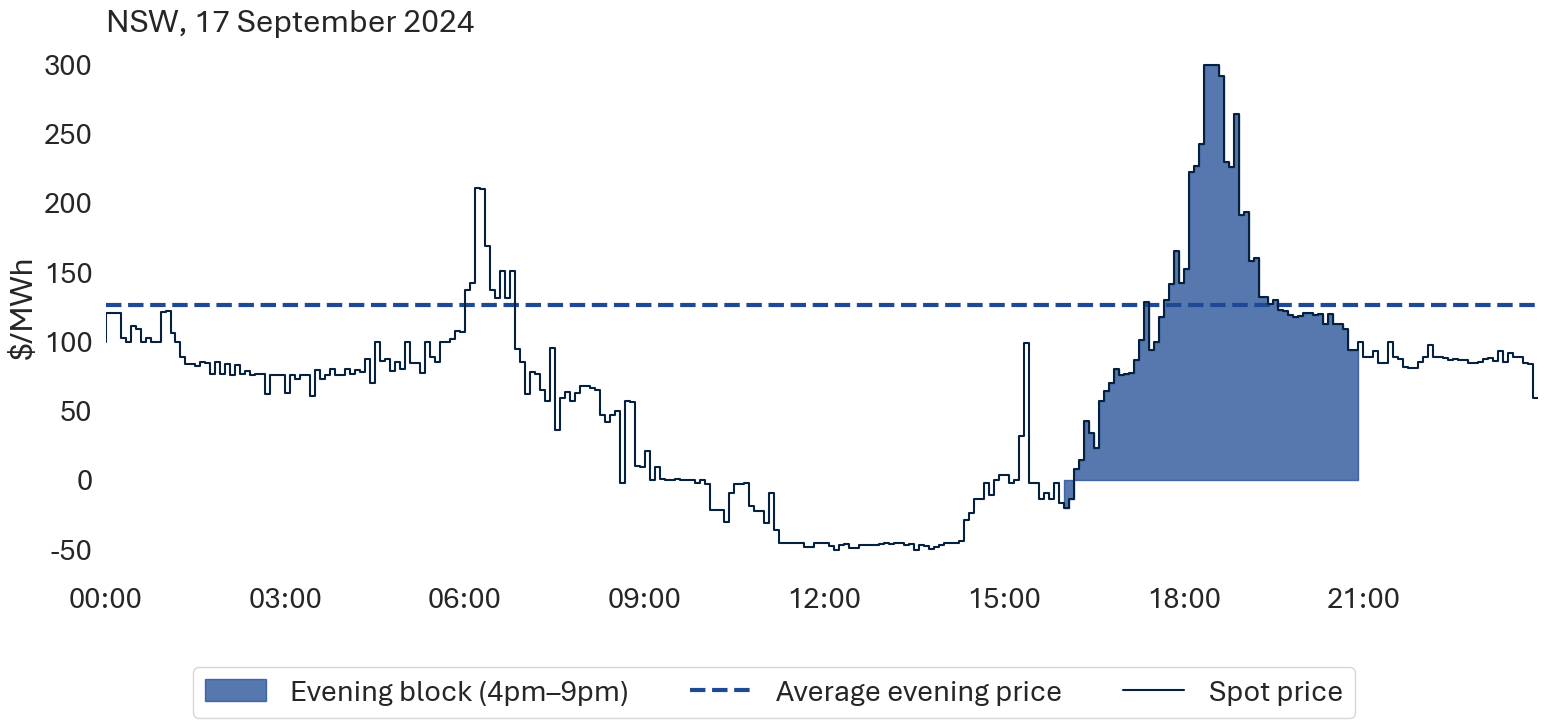

np.float64(126.73038466666667)

In [90]:
example = price_data.loc[f"2024-09-17":f"2024-09-17 23:55:00"].copy()[["NSW"]]
example["Evening"] = example.index.map(lambda t: example.at[t, "NSW"] if (t >= pd.to_datetime("2024-09-17 16:00:00")) & (t < pd.to_datetime("2024-09-17 21:00:00")) else np.nan)
fig, ax = plt.subplots(
    figsize=(16, 6.75),
    tight_layout=True)
ax.fill_between(
    x=example.index,
    y1=example["Evening"],
    y2=0,
    color="C1",
    alpha=.75,
    step="pre",
    label="Evening block (4pm–9pm)")
plt.axhline(
    example["Evening"].mean(),
    color="C1",
    linewidth=3,
    linestyle="--",
    label="Average evening price")
ax.step(
    x=example.index,
    y=example["NSW"],
    label="Spot price")
for frame in ["top", "right", "bottom", "left"]:
    ax.spines[frame].set_visible(False)
plt.title("NSW, 17 September 2024", loc="left")
plt.ylabel("$/MWh")
plt.xlabel(None)
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.125), ncol=3)
plt.xlim(example.index.min(), example.index.max())
plt.show()
save_figure(fig, f"NSW_example_evening_price_spread", charts_dir)
example["Evening"].mean()

#### Box plot interpretation

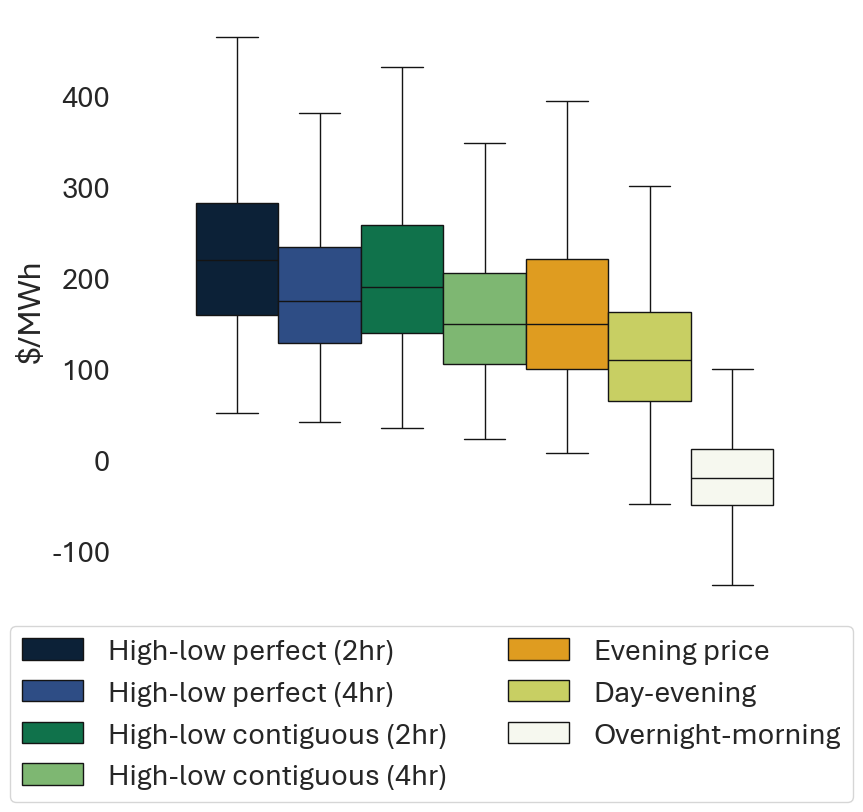

In [91]:
fig, ax = plt.subplots(
    figsize=(9, 6.75),
    tight_layout=True)
chart_data = results[
    (results["Region"] == "NSW") &
    (results["Year"] > 2023)]
sns.boxplot(
    ax=ax,
    data=chart_data,
    x="Year",
    y="Price spread",
    hue="Spread type",
    palette=["C0", "C1", "C2", "C3", "orange", "C4", "C5"],
    showfliers=False)
for frame in ["top", "right", "bottom", "left"]:
    ax.spines[frame].set_visible(False)
plt.ylabel("$/MWh")
plt.xlabel(None)
plt.xticks([])
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
handles, labels = ax.get_legend_handles_labels()
plt.legend().remove()
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.show()
save_figure(fig, "NSW_box_plot_example", charts_dir)

### Highest and lowest cost hour over time

In [92]:
# Check if analysis has been done
hourly_results_path = os.path.join(data_dir, "hourly_analysis_results.csv")
hourly_results_exist = os.path.exists(hourly_results_path)

# Empty container for analysis results with dtypes
if not hourly_results_exist:
    hourly_results = pd.DataFrame({
        "Region": pd.Series(dtype="str"),
        "Date": pd.Series(dtype="datetime64[ns]"),
        "Highest-priced hour": pd.Series(dtype="object"),
        "Lowest-priced hour": pd.Series(dtype="object")})

    # Aggregate to hourly data
    hourly_data = price_data.copy().resample("h").mean()

    # Examine each regions
    for region in regions:
        # Examine each day
        grouped = hourly_data[region].groupby(hourly_data["Date"])
        for period_date, prices in grouped:
            date_dt = period_date.to_timestamp()
            indice = len(hourly_results)
            prices.sort_values(inplace=True)
            hourly_results.at[indice, "Region"] = region
            hourly_results.at[indice, "Date"] = date_dt
            hourly_results.at[indice, "Highest-priced hour"] = prices.index[-1].hour
            hourly_results.at[indice, "Lowest-priced hour"] = prices.index[0].hour

    # Save analysis
    hourly_results.to_csv(hourly_results_path, index=False)

# Load hourly analysis results
else:
    hourly_results = pd.read_csv(
        hourly_results_path,
        parse_dates=["Date"])

# Ascribe years and quarters
hourly_results["Year"] = hourly_results["Date"].dt.year
hourly_results["Quarter"] = hourly_results["Date"].dt.to_period("Q")
hourly_results["Month"] = hourly_results["Date"].dt.to_period("M")

# Display results
hourly_results

,Region,Date,Highest-priced hour,Lowest-priced hour,Year,Quarter,Month
0,NSW,2015-01-01,16,5,2015,2015Q1,2015-01
1,NSW,2015-01-02,13,5,2015,2015Q1,2015-01
2,NSW,2015-01-03,16,5,2015,2015Q1,2015-01
3,NSW,2015-01-04,13,5,2015,2015Q1,2015-01
4,NSW,2015-01-05,16,1,2015,2015Q1,2015-01
...,...,...,...,...,...,...,...
14607,VIC,2024-12-27,20,13,2024,2024Q4,2024-12
14608,VIC,2024-12-28,23,9,2024,2024Q4,2024-12
14609,VIC,2024-12-29,23,14,2024,2024Q4,2024-12
14610,VIC,2024-12-30,23,10,2024,2024Q4,2024-12


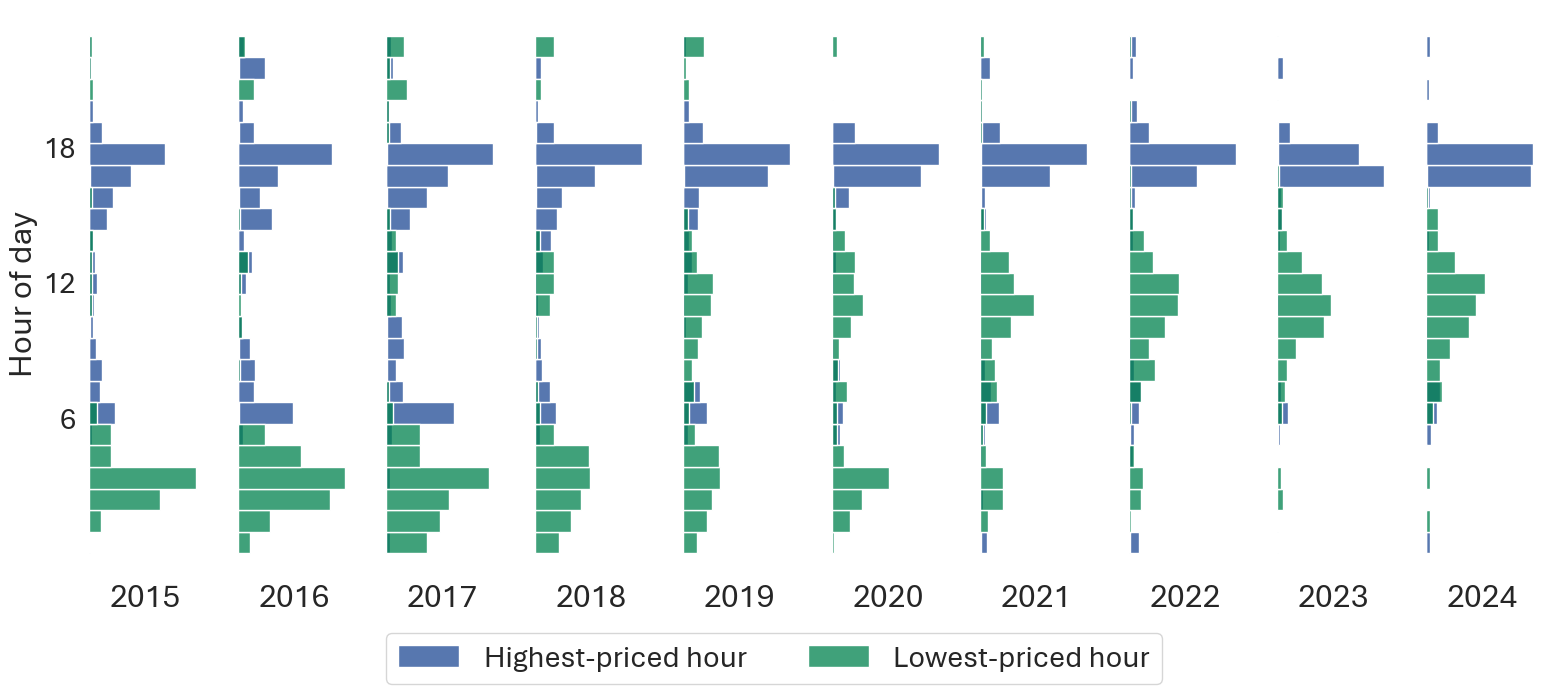

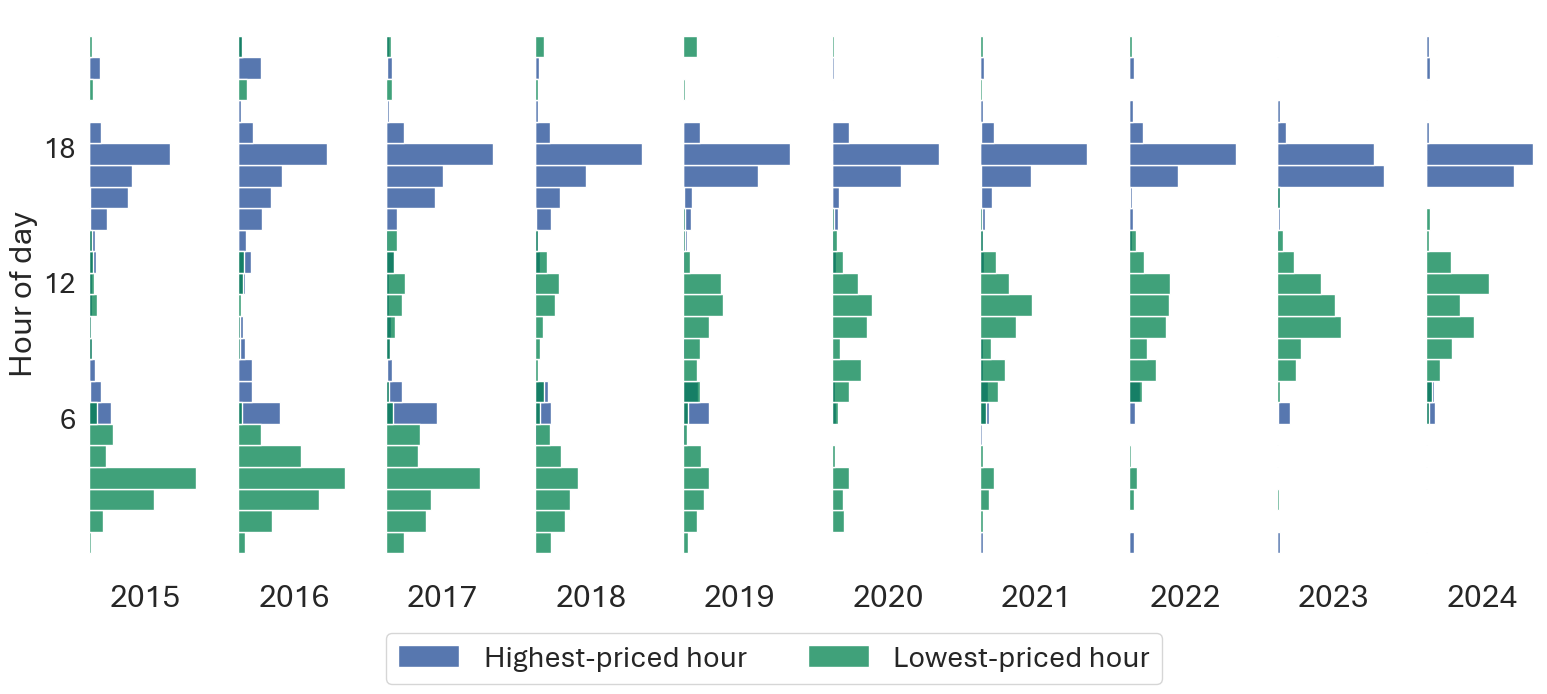

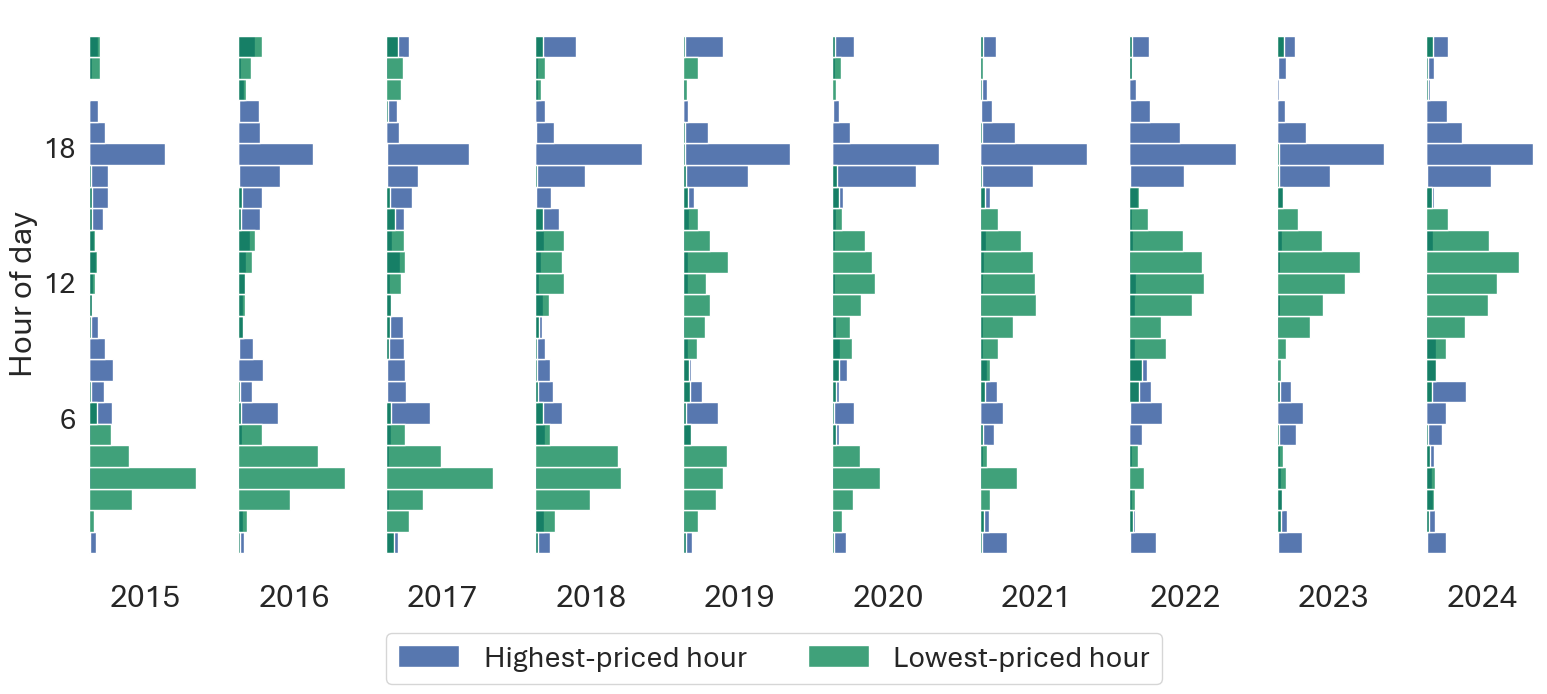

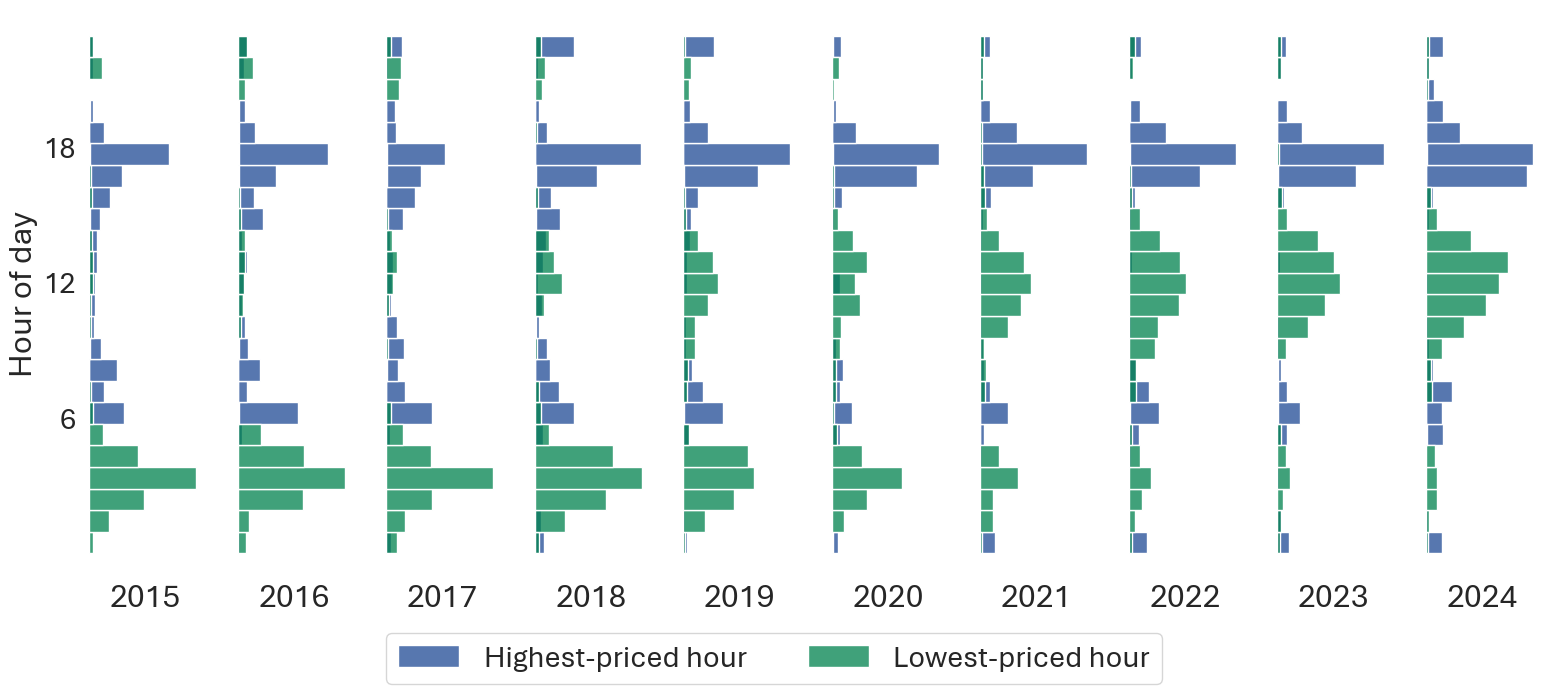

In [93]:
for region in regions:
    fig, ax = plt.subplots(
        1, 10,
        figsize=(16, 6.75),
        tight_layout=True,
        sharey=True)
    region_results = hourly_results[
        hourly_results["Region"] == region].copy()
    for i, year in enumerate(range(2015, 2025)):        
        axis = ax[i]
        year_results = region_results[
            region_results["Year"] == year].copy().iloc[:, [2, 3]]
        sns.histplot(
            ax=axis,
            data=year_results,
            y="Highest-priced hour",
            color="C1",
            alpha=0.75,
            bins=24,
            binrange=(0, 23),
            label="Highest-priced hour")
        sns.histplot(
            ax=axis,
            data=year_results,
            y="Lowest-priced hour",
            color="C2",
            alpha=0.75,
            bins=24,
            binrange=(0, 23),
            label="Lowest-priced hour")
        for frame in ["top", "right", "bottom", "left"]:
            axis.spines[frame].set_visible(False)
        handles, labels = axis.get_legend_handles_labels()
        axis.set_ylabel("Hour of day")
        axis.set_yticks([6, 12, 18])
        axis.set_xlabel(year)
        axis.set_xticks([])
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.075), ncol=2)
    plt.show()
    save_figure(fig, f"{region}_highest_lowest_cost_hours_annually", charts_dir)

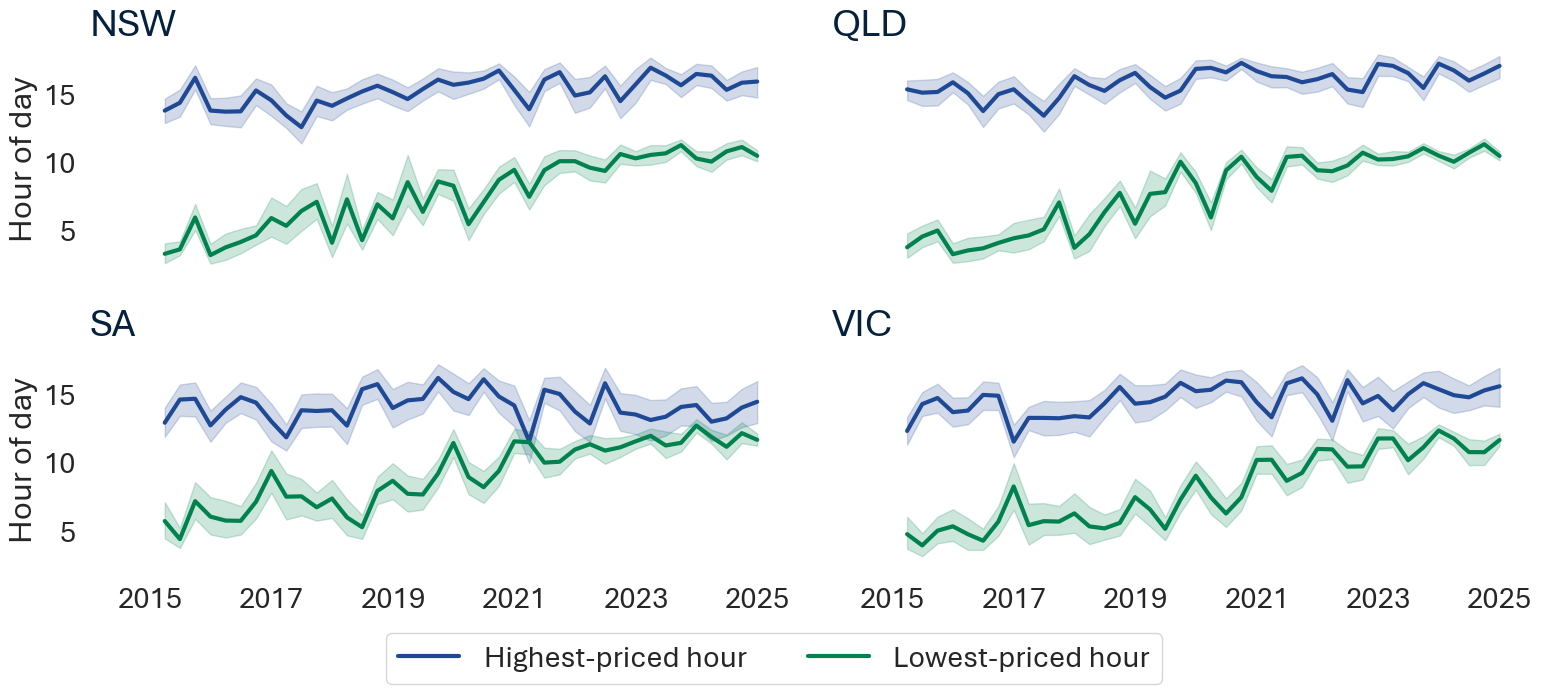

In [94]:
fig, ax = plt.subplots(
    2, 2,
    figsize=(16, 6.75),
    tight_layout=True,
    sharex=True,
    sharey=True)
for i, region in enumerate(regions):
    axis = ax[i // 2, i % 2]
    chart_data = hourly_results[
        hourly_results["Region"] == region].copy().melt(
        id_vars=["Date", "Year", "Quarter", "Month"],
        var_name="Hour type",
        value_name="Hour",
        value_vars=["Highest-priced hour", "Lowest-priced hour"])
    chart_data["Quarter"] = chart_data["Quarter"].dt.to_timestamp() + pd.offsets.QuarterEnd()
    sns.lineplot(
        ax=axis,
        data=chart_data,
        x="Quarter",
        y="Hour",
        palette=["C1", "C2"],
        linewidth=3,
        hue="Hour type")
    for frame in ["top", "right", "bottom", "left"]:
        axis.spines[frame].set_visible(False)
    axis.set_ylabel("Hour of day")
    axis.set_xlabel(None)
    handles, labels = axis.get_legend_handles_labels()
    axis.get_legend().remove()
    axis.set_xticks(axis.get_xticks())
    axis.set_xticklabels([(i + 2014 if i % 2 == 1 else "") for i in range(12)])
    axis.set_title(region, fontsize="large", loc="left", color="C0")
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.075), ncol=2)
plt.show()
save_figure(fig, "highest_lowest_cost_hours_quarterly", charts_dir)